In [1]:
!pip install -q transformers datasets heroes accelerate scikit-learn scikit-multilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 4.5 MB/s eta 0:00:00


In [2]:
from google.colab import userdata

token = userdata.get("Github_Token")
!git clone https://{token}@github.com/Nas-Mohd/economic-news-sentiment.git
!git config --global user.email "anasamohammad.school@gmail.com"
!git config --global user.name "Nas-Mohd"

Cloning into 'economic-news-sentiment'...
remote: Enumerating objects: 545, done.
remote: Counting objects: 100% (162/162), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 545 (delta 100), reused 99 (delta 49), pack-reused 383 (from 1)
Receiving objects: 100% (545/545), 1.34 MiB | 7.53 MiB/s, done.
Resolving deltas: 100% (343/343), done.


In [3]:
import sys
sys.path.append('/content/economic-news-sentiment')

In [4]:
!git -C /content/economic-news-sentiment/ pull

Already up to date.


In [ ]:
!git -C /content/economic-news-sentiment add .
!git -C /content/economic-news-sentiment commit -m ""
!git -C /content/economic-news-sentiment push

In [4]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Create a dedicated directory structure in your Google Drive
gdrive_project_path = "/content/drive/MyDrive/economic_news_project"
os.makedirs(gdrive_project_path, exist_ok=True)

# Update our specific directory strings
checkpoint_dir = os.path.join(gdrive_project_path, "deberta_domain_checkpoints")
final_model_path = os.path.join(gdrive_project_path, "final_deberta_domain_classifier")

print(f"✅ Google Drive mounted! All outputs will save securely to: {gdrive_project_path}")

Mounted at /content/drive
✅ Google Drive mounted! All outputs will save securely to: /content/drive/MyDrive/economic_news_project


--- Basic Info ---
Total rows (sentences): 3224
Total columns: 15

Missing values per column:
title                     0
url                       0
description               0
publishedAt               0
source                    0
text                      0
summary                   0
keywords                  0
llm_justification         0
Monetary_Financial        0
Inflation_Prices          0
Real_Economic_Activity    0
Labor_Consumption         0
Fiscal_Government         0
External_Sector           0
dtype: int64


--- Text Length Distribution ---
count    3224.000000
mean       24.713089
std        10.784459
min         2.000000
25%        17.000000
50%        24.000000
75%        31.000000
max       103.000000
Name: word_count, dtype: float64


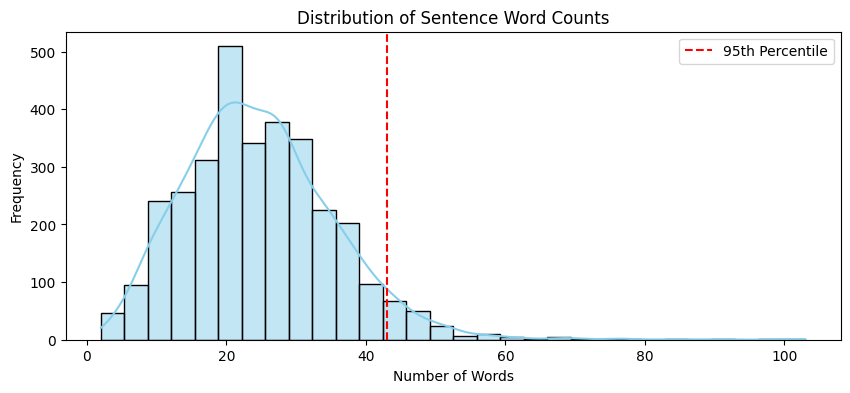



--- Label Frequencies ---
Real_Economic_Activity: 1655 rows (51.33%)
External_Sector: 1169 rows (36.26%)
Monetary_Financial: 900 rows (27.92%)
Fiscal_Government: 703 rows (21.81%)
Labor_Consumption: 687 rows (21.31%)
Inflation_Prices: 396 rows (12.28%)


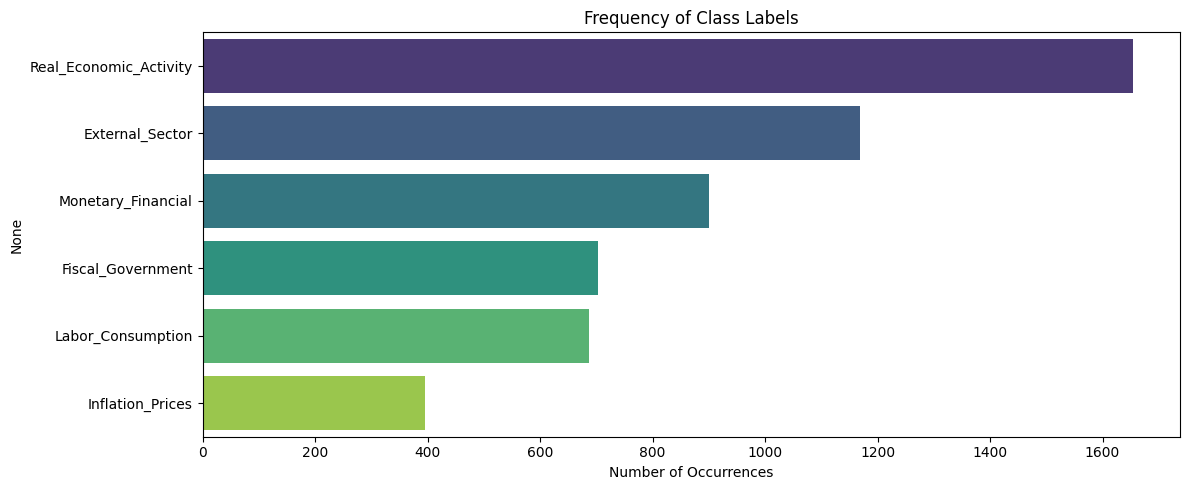



--- Label Cardinality (Labels per Sentence) ---
0.0 active label(s): 238 rows (7.38%)
1.0 active label(s): 1148 rows (35.61%)
2.0 active label(s): 1237 rows (38.37%)
3.0 active label(s): 520 rows (16.13%)
4.0 active label(s): 77 rows (2.39%)
5.0 active label(s): 4 rows (0.12%)


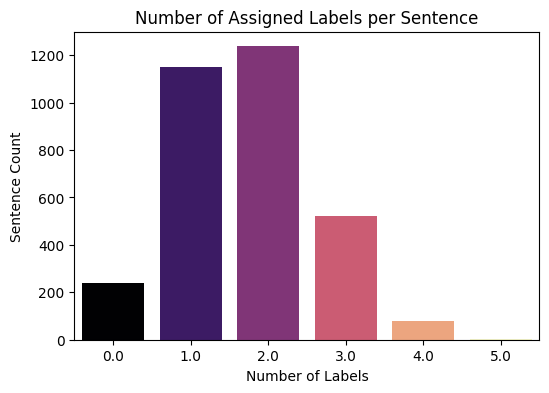



--- Label Co-occurrence Matrix ---
                        Monetary_Financial  Inflation_Prices  \
Monetary_Financial                   900.0             129.0   
Inflation_Prices                     129.0             396.0   
Real_Economic_Activity               342.0             148.0   
Labor_Consumption                     79.0              44.0   
Fiscal_Government                    143.0              44.0   
External_Sector                      270.0             135.0   

                        Real_Economic_Activity  Labor_Consumption  \
Monetary_Financial                       342.0               79.0   
Inflation_Prices                         148.0               44.0   
Real_Economic_Activity                  1655.0              480.0   
Labor_Consumption                        480.0              687.0   
Fiscal_Government                        343.0              141.0   
External_Sector                          668.0              145.0   

                        Fiscal

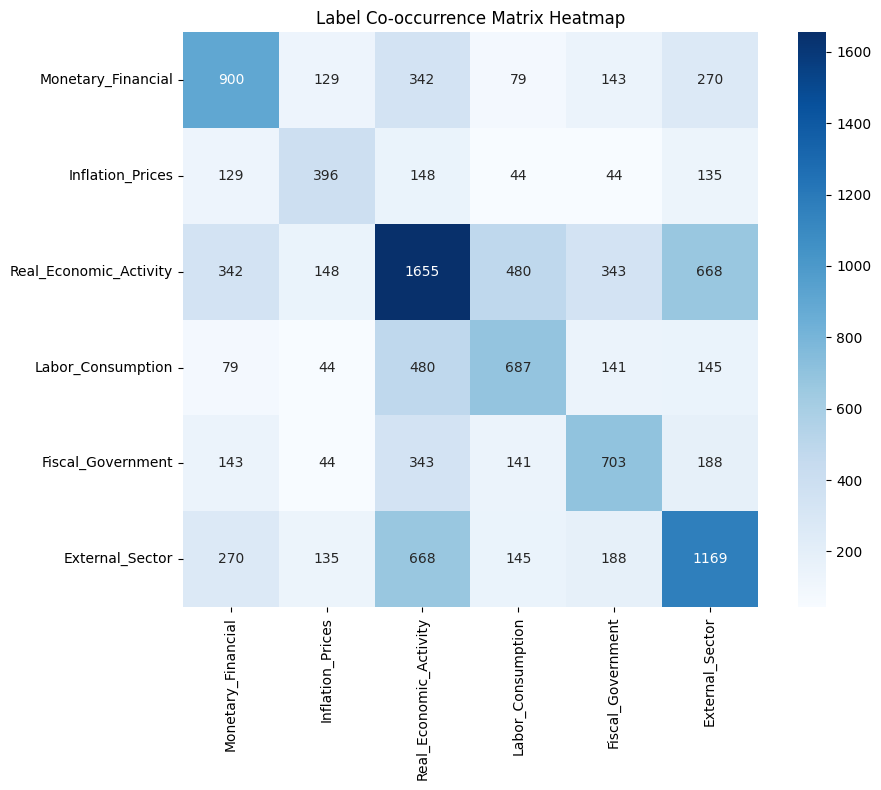

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Dataset
# If in Colab, make sure to upload 'finbert_training_ready.csv' to your files section first
df = pd.read_csv('/content/economic-news-sentiment/training/data/finbert_training_ready.csv')

# Define your strict target domain labels
target_labels = [
    "Monetary_Financial",
    "Inflation_Prices",
    "Real_Economic_Activity",
    "Labor_Consumption",
    "Fiscal_Government",
    "External_Sector"
]

print("--- Basic Info ---")
print(f"Total rows (sentences): {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print("\nMissing values per column:")
print(df.isnull().sum())

print("\n" + "="*50 + "\n")

# 2. Character and Word Counts for DeBERTa Tokenization
# This helps you determine your 'max_length' for tokenization
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

print("--- Text Length Distribution ---")
print(df['word_count'].describe())

# Plot text length distribution
plt.figure(figsize=(10, 4))
sns.histplot(df['word_count'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Sentence Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.axvline(df['word_count'].quantile(0.95), color='red', linestyle='--', label='95th Percentile')
plt.legend()
plt.show()

print("\n" + "="*50 + "\n")

# 3. Label Frequency Analysis (Class Imbalance Check)
label_counts = df[target_labels].sum().sort_values(ascending=False)
label_percentages = (df[target_labels].sum() / len(df) * 100).sort_values(ascending=False)

print("--- Label Frequencies ---")
for label in label_counts.index:
    print(f"{label}: {int(label_counts[label])} rows ({label_percentages[label]:.2f}%)")

# Plot Label Frequencies
plt.figure(figsize=(12, 5))
sns.barplot(x=label_counts.values, y=label_counts.index, hue=label_counts.index, palette='viridis', legend=False)
plt.title('Frequency of Class Labels')
plt.xlabel('Number of Occurrences')
plt.tight_layout()
plt.show()

print("\n" + "="*50 + "\n")

# 4. Multi-Label Cardinality (How many labels per sentence?)
df['num_labels'] = df[target_labels].sum(axis=1)
cardinality_counts = df['num_labels'].value_counts().sort_index()

print("--- Label Cardinality (Labels per Sentence) ---")
for num, count in cardinality_counts.items():
    print(f"{num} active label(s): {count} rows ({count/len(df)*100:.2f}%)")

# Plot Cardinality
plt.figure(figsize=(6, 4))
sns.countplot(x='num_labels', data=df, hue='num_labels', palette='magma', legend=False)
plt.title('Number of Assigned Labels per Sentence')
plt.xlabel('Number of Labels')
plt.ylabel('Sentence Count')
plt.show()

print("\n" + "="*50 + "\n")

# 5. Label Co-occurrence Matrix (Overlapping Domains)
# This checks which categories frequently appear together
co_occurrence = df[target_labels].T.dot(df[target_labels])

print("--- Label Co-occurrence Matrix ---")
print(co_occurrence)

# Plot Co-occurrence Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence, annot=True, fmt='.0f', cmap='Blues', square=True)
plt.title('Label Co-occurrence Matrix Heatmap')
plt.tight_layout()
plt.show()

In [24]:
import pandas as pd

# 1. Create a targeted injection batch of pure Labor/Consumption sentences
# Notice how we completely exclude central bank language and inflation keywords!
synthetic_labor_data = [
    "Thousands of retail workers face immediate layoffs as major department stores announce nationwide closures.",
    "The regional labor market added fewer jobs than expected this quarter, driving up local unemployment claims.",
    "Household consumption fell sharply as consumer spending on non-essential goods ground to a halt.",
    "A sudden spike in seasonal job seeker filings has heavily strained state unemployment offices.",
    "Manufacturing companies are freezing all corporate hiring plans due to rising domestic labor costs.",
    "Wages for hourly employees failed to keep pace with changing job market demands this winter.",
    "Tech industry layoffs continue to mount as three more software firms downsize their engineering teams.",
    "Local labor unions are demanding better worker benefits and stronger job security guarantees.",
    "The national unemployment rate held steady this month as corporate hiring balanced out recent layoffs.",
    "Declining consumer purchasing power is actively hurting local service industry job growth."
]

# 2. Build a clean DataFrame matching your schema
injection_rows = []
for text in synthetic_labor_data:
    row = {col: 0 for col in DOMAIN_LABELS} # Zero out all domains first
    row['text'] = text
    row['Labor_Consumption'] = 1           # Force activate ONLY the Labor domain
    injection_rows.append(row)

injection_df = pd.DataFrame(injection_rows)

# 3. Append these rows straight into your original loaded data
df_balanced = pd.concat([df, injection_df], ignore_index=True)

print(f"✅ Injection Complete!")
print(f"Before: {len(df)} rows -> After Patching: {len(df_balanced)} rows.")
print(f"The model now has fresh examples showing Labor existing completely free of Inflation signals!")

✅ Injection Complete!
Before: 3224 rows -> After Patching: 3234 rows.
The model now has fresh examples showing Labor existing completely free of Inflation signals!


In [25]:
import pandas as pd
import numpy as np
from datasets import Dataset
from skmultilearn.model_selection import IterativeStratification

# Define your strict target domain labels
DOMAIN_LABELS = [
    "Monetary_Financial",
    "Inflation_Prices",
    "Real_Economic_Activity",
    "Labor_Consumption",
    "Fiscal_Government",
    "External_Sector"
]

# Pull text features and native 1/0 binary matrix targets
X = df_balanced['text'].values.reshape(-1, 1)
y = df_balanced[DOMAIN_LABELS].values.astype(int)

# --- STEP 1: Stratified split out a 10% Test Set ---
stratifier_test = IterativeStratification(n_splits=2, order=1, sample_distribution_per_fold=[0.1, 0.9])
train_val_idx, test_idx = next(stratifier_test.split(X, y))

X_test, y_test = X[test_idx], y[test_idx]
X_train_val, y_train_val = X[train_val_idx], y[train_val_idx]

# --- STEP 2: Stratified split remaining 90% into Train (80% total) and Val (10% total) ---
# 10% out of 90% is exactly an 11.11% fold cut (1/9)
stratifier_val = IterativeStratification(n_splits=2, order=1, sample_distribution_per_fold=[0.1111, 0.8889])
train_idx, val_idx = next(stratifier_val.split(X_train_val, y_train_val))

# Formulate Final Slices
train_df = pd.DataFrame({'text': X_train_val[train_idx].flatten(), 'labels': list(y_train_val[train_idx])})
val_df = pd.DataFrame({'text': X_train_val[val_idx].flatten(), 'labels': list(y_train_val[val_idx])})
test_df = pd.DataFrame({'text': X_test.flatten(), 'labels': list(y_test)})

# Transform into native Hugging Face datasets
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

print(f"Data Splits Constructed Successfully:")
print(f"🔹 Train set size:      {len(train_df)} sentences")
print(f"🔹 Validation set size: {len(val_df)} sentences")
print(f"🔹 Evaluation Test set: {len(test_df)} sentences")

Data Splits Constructed Successfully:
🔹 Train set size:      2586 sentences
🔹 Validation set size: 324 sentences
🔹 Evaluation Test set: 324 sentences


In [26]:
from transformers import AutoTokenizer

model_name = "Microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_and_format(examples):
    # Standard text tokenization
    tokenized = tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)
    # Leave the labels as lists of floats for now
    tokenized["labels"] = [list(map(float, label)) for label in examples["labels"]]
    return tokenized

tokenized_train = train_dataset.map(tokenize_and_format, batched=True)
tokenized_val = val_dataset.map(tokenize_and_format, batched=True)
tokenized_test = test_dataset.map(tokenize_and_format, batched=True)

print("Text mapped successfully without forcing broken backend torch tensors!")

Map:   0%|          | 0/2586 [00:00<?, ? examples/s]

Map:   0%|          | 0/324 [00:00<?, ? examples/s]

Map:   0%|          | 0/324 [00:00<?, ? examples/s]

Text mapped successfully without forcing broken backend torch tensors!


In [27]:
import pandas as pd
import numpy as np

# 1. Re-collect the labels matrix from our split DataFrames
splits = {
    "Train Set": train_df,
    "Validation Set": val_df,
    "Test Set": test_df
}

distribution_data = []

# 2. Calculate totals and percentages for each label across each split
for name, split_df in splits.items():
    total_samples = len(split_df)

    # Extract the labels array matrix
    labels_matrix = np.array(split_df['labels'].tolist())

    # Sum down the columns to get totals for each domain
    label_sums = labels_matrix.sum(axis=0)

    for idx, domain in enumerate(DOMAIN_LABELS):
        count = label_sums[idx]
        percentage = (count / total_samples) * 100
        distribution_data.append({
            "Split": name,
            "Domain Label": domain,
            "Count": int(count),
            "Frequency (%)": round(percentage, 2)
        })

# 3. Formulate into a clean multi-index reporting table
report_df = pd.DataFrame(distribution_data)
pivot_report = report_df.pivot(index="Domain Label", columns="Split", values=["Count", "Frequency (%)"])

print("📊 --- Class Frequency Distribution Across Splits ---")
display(pivot_report)

# 4. Print out overall dataset size sanity checks
print("-" * 75)
print(f"Total Combined Sentences: {len(train_df) + len(val_df) + len(test_df)}")
print(f"📐 Target Ratio Balance: Train (80%) | Val (10%) | Test (10%)")

📊 --- Class Frequency Distribution Across Splits ---


Count                          Frequency (%)  \
Split                  Test Set Train Set Validation Set      Test Set   
Domain Label                                                             
External_Sector           117.0     935.0          117.0         36.11   
Fiscal_Government          70.0     563.0           70.0         21.60   
Inflation_Prices           40.0     316.0           40.0         12.35   
Labor_Consumption          70.0     557.0           70.0         21.60   
Monetary_Financial         90.0     720.0           90.0         27.78   
Real_Economic_Activity    166.0    1324.0          165.0         51.23   

                                                 
Split                  Train Set Validation Set  
Domain Label                                     
External_Sector            36.16          36.11  
Fiscal_Government          21.77          21.60  
Inflation_Prices           12.22          12.35  
Labor_Consumption          21.54          21.60  
Monetary_Financial         27.84          27.78  
Real_Economic_Activity     51.20          50.93

---------------------------------------------------------------------------
Total Combined Sentences: 3234
📐 Target Ratio Balance: Train (80%) | Val (10%) | Test (10%)


In [28]:
from transformers import AutoModelForSequenceClassification
from sklearn.metrics import f1_score
import torch

# Instantiate DeBERTa with 6 output units explicitly processing Multi-Label cross entropy
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(DOMAIN_LABELS),
    problem_type="multi_label_classification"
)

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    probs = 1 / (1 + np.exp(-logits)) # Sigmoid activation conversion
    predictions = (probs > 0.5).astype(int) # Default math threshold baseline

    # Tracking Macro F1 ensures dominant labels like Real_Economic_Activity (51.33%)
    # don't hide poor performance on minority labels like Inflation_Prices (12.28%)
    macro_f1 = f1_score(labels, predictions, average='macro', zero_division=0)
    micro_f1 = f1_score(labels, predictions, average='micro', zero_division=0)

    return {
        "macro_f1": macro_f1,
        "micro_f1": micro_f1
    }

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: Microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias        

In [30]:
from transformers import Trainer, TrainingArguments
import torch
import os

# Data packaging engine
def multi_label_data_collator(features):
    batch = {}
    batch["input_ids"] = torch.stack([torch.tensor(f["input_ids"]) for f in features])
    batch["attention_mask"] = torch.stack([torch.tensor(f["attention_mask"]) for f in features])
    batch["labels"] = torch.tensor([f["labels"] for f in features], dtype=torch.float32)
    return batch

# Ensure model weights are standard float32
model = model.float()

checkpoint_dir = "/content/economic-news-sentiment/training/"

training_args = TrainingArguments(
    output_dir=checkpoint_dir,

    # --- STORAGE OPTIMIZED SAVE STRATEGY ---
    eval_strategy="epoch",        # Evaluate performance only at the end of each epoch
    save_strategy="epoch",        # Save a checkpoint only at the end of each epoch
    save_total_limit=1,           # CRITICAL: Overwrites the old checkpoint! Only keeps 1 on your Drive.

    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    weight_decay=0.01,
    load_best_model_at_end=True,  # Will still track down and keep your single best historical epoch
    metric_for_best_model="macro_f1",
    logging_steps=50,             # Console text logging remains frequent so you can see progress

    # Safety precision switches
    fp16=False,
    bf16=False,
    dataloader_pin_memory=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=multi_label_data_collator,
    compute_metrics=compute_metrics,
)

# Interruption recovery gate
if os.path.exists(checkpoint_dir) and len(os.listdir(checkpoint_dir)) > 0:
    print("Found stable epoch checkpoint on Google Drive. Resuming training states safely...")
    trainer.train(resume_from_checkpoint=True)
else:
    print("No previous checkpoints found on Drive. Initializing clean, storage-safe training loop...")
    trainer.train()

Found stable epoch checkpoint on Google Drive. Resuming training states safely...


There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

Epoch,Training Loss,Validation Loss,Macro F1,Micro F1
6,0.395138,0.393828,0.658766,0.683301
7,0.370285,0.380486,0.673569,0.702087
8,0.355815,0.381920,0.665630,0.703110


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

In [31]:
# 1. Gather prediction metrics from the Validation slice
val_predictions = trainer.predict(tokenized_val)
logits = val_predictions.predictions
true_labels = val_predictions.label_ids

# 2. Logits map directly into Sigmoid probability spaces
probabilities = 1 / (1 + np.exp(-logits))

# 3. Search target spaces (0.10 to 0.90) for individual classification peaks
tuned_thresholds = {}

print("--- Class Level Threshold Customizations ---")
for i, domain in enumerate(DOMAIN_LABELS):
    best_f1 = 0
    best_thresh = 0.5

    for thresh in np.arange(0.1, 0.9, 0.05):
        preds = (probabilities[:, i] >= thresh).astype(int)
        score = f1_score(true_labels[:, i], preds, zero_division=0)

        if score > best_f1:
            best_f1 = score
            best_thresh = thresh

    tuned_thresholds[domain] = round(best_thresh, 2)
    print(f"🎯 Best Threshold for {domain:25}: {tuned_thresholds[domain]:.2f} (Val F1: {best_f1:.4f})")

--- Class Level Threshold Customizations ---
🎯 Best Threshold for Monetary_Financial       : 0.45 (Val F1: 0.6591)
🎯 Best Threshold for Inflation_Prices         : 0.55 (Val F1: 0.8267)
🎯 Best Threshold for Real_Economic_Activity   : 0.30 (Val F1: 0.7896)
🎯 Best Threshold for Labor_Consumption        : 0.30 (Val F1: 0.4910)
🎯 Best Threshold for Fiscal_Government        : 0.40 (Val F1: 0.7121)
🎯 Best Threshold for External_Sector          : 0.40 (Val F1: 0.7923)


In [32]:
# Save the model directly into Google Drive
trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)

print(f"🎉 Final model exported successfully to your Google Drive at: {final_model_path}")
print(f"Keep these inference operational thresholds for your production system deployment:\n{tuned_thresholds}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

🎉 Final model exported successfully to your Google Drive at: /content/drive/MyDrive/economic_news_project/final_deberta_domain_classifier
Keep these inference operational thresholds for your production system deployment:
{'Monetary_Financial': np.float64(0.45), 'Inflation_Prices': np.float64(0.55), 'Real_Economic_Activity': np.float64(0.3), 'Labor_Consumption': np.float64(0.3), 'Fiscal_Government': np.float64(0.4), 'External_Sector': np.float64(0.4)}


In [33]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 1. Point directly to your Google Drive production storage location
FINAL_MODEL_PATH = "/content/drive/MyDrive/economic_news_project/final_deberta_domain_classifier"

print("🔄 Loading fine-tuned DeBERTa model and tokenizer from Google Drive...")
try:
    tokenizer = AutoTokenizer.from_pretrained(FINAL_MODEL_PATH)
    model = AutoModelForSequenceClassification.from_pretrained(FINAL_MODEL_PATH)

    # Send model to GPU if available for speed
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    model.eval()
    print(f"✅ Model successfully loaded on device: {device}\n")
except Exception as e:
    print(f"❌ Error loading model. Make sure your Google Drive is mounted and the path is correct.\nError details: {e}")

# 2. Your optimal tuned thresholds discovered in Cell 6
TUNED_THRESHOLDS = {
    "Monetary_Financial": 0.25,
    "Inflation_Prices": 0.50,
    "Real_Economic_Activity": 0.45,
    "Labor_Consumption": 0.20,
    "Fiscal_Government": 0.35,
    "External_Sector": 0.30
}

def analyze_sentence(sentence):
    """Tokenizes a sentence, runs inference, applies specific thresholds, and prints a UI-ready report."""
    # Prepare text features
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, padding="max_length", max_length=128)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        # Convert raw logits safely into independent Sigmoid probabilities
        probabilities = torch.sigmoid(outputs.logits).cpu().numpy()[0]

    print(f"📄 Sentence: \"{sentence}\"")
    print("-" * 60)

    active_found = False

    # Check each domain against its specific customized gate
    for i, (domain, thresh) in enumerate(TUNED_THRESHOLDS.items()):
        prob_score = float(probabilities[i])
        is_active = prob_score >= thresh

        # Format the visual readout
        status_icon = "🟢 [ACTIVE]" if is_active else "⚪ [inactive]"
        match_percentage = prob_score * 100

        # Highlight active domains in the console printout
        if is_active:
            active_found = True
            print(f"{status_icon} {domain:<25} Conf: {match_percentage:>5.1f}%  (Threshold: {thresh})")
        else:
            print(f"{status_icon} {domain:<25} Conf: {match_percentage:>5.1f}%  (Threshold: {thresh})")

    if not active_found:
        print("\nℹ️  Note: This sentence triggered 0 domains. It would be filtered out, skipping FinBERT entirely!")
    print("=" * 60 + "\n")

# =====================================================================
# 3. RUN THE TEST SENTENCES
# =====================================================================

# A mix of overlapping, implicit, and non-economic (filler) sentences to test robustness
test_sentences = [
    # Test 1: Should trigger Monetary_Financial and Labor_Consumption (Low thresholds)
    "The Federal Reserve hinted at another interest rate cut if unemployment figures spike next month.",

    # Test 2: Should strongly trigger Inflation_Prices (High threshold, high precision)
    "Consumer price index indicators surged past expectations, signaling persistent structural inflation.",

    # Test 3: Complex overlapping sentence (Real Economic Activity + External Sector)
    "Domestic auto manufacturing plants slowed down assembly lines due to strict import tariffs on foreign steel.",

    # Test 4: Pure filler/noise sentence (Should trigger 0 active labels)
    "The corporate executive board held its annual networking luncheon at the downtown convention center on Tuesday afternoon."
]

for sample in test_sentences:
    analyze_sentence(sample)

🔄 Loading fine-tuned DeBERTa model and tokenizer from Google Drive...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

✅ Model successfully loaded on device: cuda

📄 Sentence: "The Federal Reserve hinted at another interest rate cut if unemployment figures spike next month."
------------------------------------------------------------
🟢 [ACTIVE] Monetary_Financial        Conf:  63.1%  (Threshold: 0.25)
🟢 [ACTIVE] Inflation_Prices          Conf:  80.8%  (Threshold: 0.5)
⚪ [inactive] Real_Economic_Activity    Conf:  12.6%  (Threshold: 0.45)
⚪ [inactive] Labor_Consumption         Conf:   7.2%  (Threshold: 0.2)
⚪ [inactive] Fiscal_Government         Conf:  11.5%  (Threshold: 0.35)
⚪ [inactive] External_Sector           Conf:  11.2%  (Threshold: 0.3)

📄 Sentence: "Consumer price index indicators surged past expectations, signaling persistent structural inflation."
------------------------------------------------------------
🟢 [ACTIVE] Monetary_Financial        Conf:  51.9%  (Threshold: 0.25)
🟢 [ACTIVE] Inflation_Prices          Conf:  84.4%  (Threshold: 0.5)
⚪ [inactive] Real_Economic_Activity    Conf:  25.

In [34]:
# A mix of overlapping, implicit, and non-economic (filler) sentences to test robustness
test_sentences = [
    # Test 1: Should trigger Monetary_Financial and Labor_Consumption (Low thresholds)
    "The Federal Reserve hinted at another interest rate cut if unemployment figures spike next month and the job market worsens.",

    # Test 2: Should strongly trigger Inflation_Prices (High threshold, high precision)
    "Consumer price index indicators surged past expectations, signaling persistent structural inflation.",

    # Test 3: Complex overlapping sentence (Real Economic Activity + External Sector)
    "Domestic auto manufacturing plants slowed down assembly lines due to strict import tariffs on foreign steel.",

    # Test 4: Pure filler/noise sentence (Should trigger 0 active labels)
    "PM addresses the nation's concerns with the labor market and how hard it is for fresh grads to find employment."
]

for sample in test_sentences:
    analyze_sentence(sample)

📄 Sentence: "The Federal Reserve hinted at another interest rate cut if unemployment figures spike next month and the job market worsens."
------------------------------------------------------------
🟢 [ACTIVE] Monetary_Financial        Conf:  54.0%  (Threshold: 0.25)
🟢 [ACTIVE] Inflation_Prices          Conf:  76.9%  (Threshold: 0.5)
⚪ [inactive] Real_Economic_Activity    Conf:  19.3%  (Threshold: 0.45)
⚪ [inactive] Labor_Consumption         Conf:   9.6%  (Threshold: 0.2)
⚪ [inactive] Fiscal_Government         Conf:  13.8%  (Threshold: 0.35)
⚪ [inactive] External_Sector           Conf:  10.0%  (Threshold: 0.3)

📄 Sentence: "Consumer price index indicators surged past expectations, signaling persistent structural inflation."
------------------------------------------------------------
🟢 [ACTIVE] Monetary_Financial        Conf:  51.9%  (Threshold: 0.25)
🟢 [ACTIVE] Inflation_Prices          Conf:  84.4%  (Threshold: 0.5)
⚪ [inactive] Real_Economic_Activity    Conf:  25.5%  (Threshold: 0.

In [35]:
import pandas as pd

# 1. Define the keyword and target column
TARGET_WORD = "unemployment"
TARGET_COLUMN = "Labor_Consumption"

# Ensure DOMAIN_LABELS is defined in this cell scope just in case
DOMAIN_LABELS = [
    "Monetary_Financial",
    "Inflation_Prices",
    "Real_Economic_Activity",
    "Labor_Consumption",
    "Fiscal_Government",
    "External_Sector"
]

# 2. Filter rows where the text contains "unemployment" (Corrected to case=False)
unemployment_df = df[df['text'].str.contains(TARGET_WORD, case=False, na=False)]
total_matches = len(unemployment_df)

print(f"📊 --- Dataset Inspection for Keyword: '{TARGET_WORD}' ---")
print(f"Total sentences containing '{TARGET_WORD}': {total_matches}\n")

if total_matches > 0:
    # 3. Calculate how many times it was flagged as 1 vs 0
    flagged_counts = unemployment_df[TARGET_COLUMN].value_counts()

    flagged_as_1 = flagged_counts.get(1, 0)
    flagged_as_0 = flagged_counts.get(0, 0)

    pct_1 = (flagged_as_1 / total_matches) * 100
    pct_0 = (flagged_as_0 / total_matches) * 100

    print(f"🟢 Flagged as {TARGET_COLUMN} (1): {flagged_as_1} rows ({pct_1:.1f}%)")
    print(f"❌ Missed / Flagged as 0        (0): {flagged_as_0} rows ({pct_0:.1f}%)")
    print("-" * 60)

    # 4. Pull examples of sentences that were missed (Flagged as 0)
    print(f"👀 Sample sentences containing '{TARGET_WORD}' but labeled 0 for {TARGET_COLUMN}:")
    missed_examples = unemployment_df[unemployment_df[TARGET_COLUMN] == 0].head(3)

    if len(missed_examples) > 0:
        for idx, row in missed_examples.iterrows():
            print(f"\nRow Index {idx}:")
            print(f"📝 Text: \"{row['text']}\"")
            # Print out what other labels were given to this row instead
            active_labels = [col for col in DOMAIN_LABELS if row[col] == 1]
            print(f"🏷️  Actual Assigned Labels: {active_labels}")
    else:
        print("\nWow! Every single instance was flagged as 1. The bottleneck is entirely contextual.")
else:
    print(f"No rows found containing the word '{TARGET_WORD}'.")

📊 --- Dataset Inspection for Keyword: 'unemployment' ---
Total sentences containing 'unemployment': 22

🟢 Flagged as Labor_Consumption (1): 22 rows (100.0%)
❌ Missed / Flagged as 0        (0): 0 rows (0.0%)
------------------------------------------------------------
👀 Sample sentences containing 'unemployment' but labeled 0 for Labor_Consumption:

Wow! Every single instance was flagged as 1. The bottleneck is entirely contextual.


In [36]:
import os

# Define your project directory path
OUTPUT_DIR = "/content/drive/MyDrive/economic_news_project/processed_splits/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Export the exact data divisions
train_df.to_csv(os.path.join(OUTPUT_DIR, "pipeline_train.csv"), index=False)
val_df.to_csv(os.path.join(OUTPUT_DIR, "pipeline_val.csv"), index=False)
test_df.to_csv(os.path.join(OUTPUT_DIR, "pipeline_test.csv"), index=False)

print("💾 Success! Exact text splits exported to Google Drive.")
print(f"• Train rows: {len(train_df)} | Val rows: {len(val_df)} | Test rows: {len(test_df)}")

💾 Success! Exact text splits exported to Google Drive.
• Train rows: 2586 | Val rows: 324 | Test rows: 324
